In [ ]:


!pip install -q transformers trl peft accelerate bitsandbytes datasets pyarrow tqdm

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.5/465.5 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 98.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 29.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 37.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 84.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [3]:
import pandas as pd
from datasets import load_dataset
dataset = load_dataset("Amod/mental_health_counseling_conversations")

train_test = dataset["train"].train_test_split(test_size=0.30, seed=42)

train_df = train_test["train"].to_pandas()
test_df  = train_test["test"].to_pandas()




README.md: 0.00B [00:00, ?B/s]

combined_dataset.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/3512 [00:00<?, ? examples/s]

In [5]:
dataset

DatasetDict({
    train: Dataset({
        features: ['Context', 'Response'],
        num_rows: 3512
    })
})

In [6]:
!pip install evaluate
!pip install rouge_score
!pip install bert_score
!pip install bitsandBytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 38.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 19.0.1
    Uninstalling pyarrow-19.0.1:
      Successfully uninstalled pyarrow-19.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
pylibcudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
cudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
cudf-polars-cu12 25.6.0 requires pyli

In [7]:
import pandas as pd

In [ ]:
test_df.head()

In [2]:
import os
if "COLAB_GPU" in os.environ:
  from google.colab import output
  output.enable_custom_widget_manager()

In [ ]:
import os
from huggingface_hub import notebook_login

# If running in Google Colab
if "COLAB_GPU" in os.environ:
    !huggingface-cli login
# If running locally (Jupyter, VS Code, etc.)
else:
    notebook_login() 


In [ ]:
import torch
from transformers import AutoTokenizer, Gemma3ForCausalLM, BitsAndBytesConfig
from datasets import load_dataset

In [1]:
#model_id = "google/gemma-3-270m-it"
model_id = "google/gemma-3-1b-it"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model = Gemma3ForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map="auto"
).eval()

tokenizer = AutoTokenizer.from_pretrained(model_id)


KeyboardInterrupt: 

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

In [13]:
def extract_gemma3_response(text):

    # Extract only the assistant part
    if "<|start_header_id|>assistant<|end_header_id|>" in text:
        text = text.split("<|start_header_id|>assistant<|end_header_id|>")[-1]

    # Remove any Gemma system tokens
    trash_tags = [
        "<|begin_of_text|>", "<|end_of_text|>",
        "<|start_header_id|>", "<|end_header_id|>",
        "<|eot_id|>", "<|eos_id|>"
    ]
    for t in trash_tags:
        text = text.replace(t, "")

    return text.strip()


tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

In [15]:
test_df.reset_index(drop=True, inplace=True)


In [ ]:
# for _, row in test_df.iterrows():
#   question = row["Context"]
#   # answer = row["Response"]

#   messages = [
#     {"role": "system", "content": "You are a pirate chatbot who always responds in pirate speak!"},
#     {"role": "user", "content": question},
#     # {"role": "assistant", "content": answer},
#     ]
#   input_ids = tokenizer.apply_chat_template(
#       messages,
#       add_generation_prompt=True,
#       return_tensors="pt"
# ).to(model.device)

In [18]:
test_dff

,Context,Response
0,"I get so much anxiety, and I don’t know why. I...",The are two ways that such anxiety can be deal...
1,I think about death all the time because I fee...,Feeling alone and/or isolated is almost always...
2,I am not sure if I am depressed. I don't know ...,"You are not alone, many people fear opening up..."
3,I'm in a long-distance relationship with my id...,The basic guideline for relationship satisfact...
4,I am divorced and happily remarried. Our blend...,It sounds really difficult to know that your d...
...,...,...
205,I am going through a very hard time and I'm so...,Consider yourself quite normal for feeling ove...
206,How do therapists classify the type of persona...,"This is a great question, and I am happy to ha..."
207,We rent from from my boyfriend's parents. His ...,You're expecting reasonable behaviors from you...
208,I'm going through some things with my feelings...,It sounds like you may be struggling with depr...


**single statement result**

In [32]:
messages = [
    # {
    #     "role": "system",
    #     "content": [{"type": "text",
    #                  "text": "You are a calm, empathetic mental-health support assistant.Respond with brief, caring messages that validate the user’s feelings.Avoid assumptions, judgment, or clinical advice."}]
    # },
    {
        "role": "user",
        "content": [{"type": "text", "text": sample_context}]
    }
]

# Apply chat template
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    return_tensors="pt",
    return_dict=True
)

# Send to model device (no dtype change for input_ids!)
inputs = {
    "input_ids": inputs["input_ids"].to(model.device),
    "attention_mask": inputs["attention_mask"].to(model.device)
}

# Generate clean single response
with torch.inference_mode():
    output_ids = model.generate(
        **inputs,
            max_new_tokens=150,
            do_sample=True,
            top_p=0.9,
            temperature=0.7,
            pad_token_id=tokenizer.eos_token_id
    )

decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)

clean_response = extract_gemma3_response(decoded)

print("\n=== MODEL SINGLE STATEMENT RESPONSE ===\n")
print(clean_response)


---- RAW DECODED OUTPUT ----
<|begin_of_text|><s>Context: I get so much anxiety, and I don’t know why. I feel like I can’t do anything by myself because I’m scared of the outcomes.
Response: It sounds like you’re in a situation where you’re not feeling safe. It’s important to note that there are people who can help you in this situation. If you have a friend or family member who can help you, that would be the best option. If not, you can always seek help from a therapist, social worker, or counselor.
You might be wondering, “What does the Bible


In [21]:
import torch
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
tokenizer.pad_token = tokenizer.eos_token

test_dff = test_dff.copy()
predicted_answers = []

for idx, row in tqdm(test_dff.iterrows(), total=len(test_dff), desc="Generating"):
    
    question = row["Context"]

    # correct prompt for base Llama-3.2
    manual_prompt = f"<s>Context: {question}\nResponse:"

    inputs = tokenizer(manual_prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=True,
            top_p=0.9,
            temperature=0.7,
            pad_token_id=tokenizer.eos_token_id
        )

    # FULL decode — do NOT slice token IDs for base model
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Correct extraction
    if "Response:" in decoded:
        answer = decoded.split("Response:")[1].strip()
    else:
        answer = decoded.strip()

    predicted_answers.append(answer)

test_dff["Predicted_Response"] = predicted_answers


Generating:   0%|          | 0/210 [00:00<?, ?it/s]

In [22]:
 test_dff

,Context,Response,Predicted_Response
0,"I get so much anxiety, and I don’t know why. I...",The are two ways that such anxiety can be deal...,It is natural to feel anxious when you don’t k...
1,I think about death all the time because I fee...,Feeling alone and/or isolated is almost always...,This is a very difficult topic. I am not sure ...
2,I am not sure if I am depressed. I don't know ...,"You are not alone, many people fear opening up...","If you are not sure if you are depressed, then..."
3,I'm in a long-distance relationship with my id...,The basic guideline for relationship satisfact...,"The question of what constitutes ""the perfect ..."
4,I am divorced and happily remarried. Our blend...,It sounds really difficult to know that your d...,"I don’t know the specifics of your situation, ..."
...,...,...,...
205,I am going through a very hard time and I'm so...,Consider yourself quite normal for feeling ove...,It is hard to imagine what you are going throu...
206,How do therapists classify the type of persona...,"This is a great question, and I am happy to ha...","Personality is a broad concept, and there are ..."
207,We rent from from my boyfriend's parents. His ...,You're expecting reasonable behaviors from you...,I don't think the OP has a good relationship w...
208,I'm going through some things with my feelings...,It sounds like you may be struggling with depr...,The best thing you can do is to tell people ho...


In [23]:
test_dff.to_csv("/kaggle/working/predicted_responses.csv", index=False)

In [24]:
import pandas as pd
test_dff = pd.read_csv("/kaggle/working/predicted_responses.csv")

**Evaluation**

In [25]:
import evaluate
rouge_metric = evaluate.load("rouge")
score = rouge_metric.compute(predictions =test_dff.Predicted_Response, references= test_dff.Response, use_stemmer=True )
print(score)

{'rouge1': 0.26567827187476467, 'rouge2': 0.03843303566062106, 'rougeL': 0.1438916744244365, 'rougeLsum': 0.15620787591476587}


In [26]:
bertscore = evaluate.load("bertscore")
scoreb = bertscore.compute(predictions =test_dff.Predicted_Response, references= test_dff.Response, lang='en' )


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [27]:
sum(scoreb['f1'])/len(scoreb['f1'])

0.8314388675349099

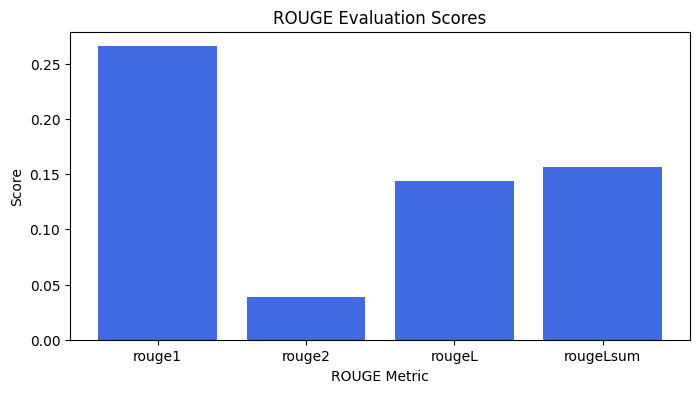

In [30]:
import matplotlib.pyplot as plt

rouge_scores = {
    "rouge1": score["rouge1"],
    "rouge2": score["rouge2"],
    "rougeL": score["rougeL"],
    "rougeLsum": score["rougeLsum"]
}

plt.figure(figsize=(8, 4))
plt.bar(rouge_scores.keys(), rouge_scores.values(), color='royalblue')
plt.title("ROUGE Evaluation Scores")
plt.ylabel("Score")
plt.xlabel("ROUGE Metric")
plt.show()
